In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
rho=0.1
sigma=0.2
T=1
S0=100
K=100


In [4]:
#Black-Scholes
def black_scholes_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price
call_price = black_scholes_call(S0, K, T, rho, sigma)
print(f"Black-Scholes Call Option Price: {call_price:.6f}")

Black-Scholes Call Option Price: 13.269677


In [5]:
#Monte Carlo
X = np.random.standard_normal(10000000)
ST = S0 * np.exp((rho - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * X)
payoff = np.maximum(ST - K, 0)
monte_carlo_price = np.exp(-rho * T) * np.mean(payoff)
#intervale de confiance
X_std=np.std(payoff)
confidence_interval = (monte_carlo_price - 1.96 * X_std / np.sqrt(len(payoff)), monte_carlo_price + 1.96 * X_std / np.sqrt(len(payoff)))
print(f"Monte Carlo Call Option Price: {monte_carlo_price:.6f}")
print(f"95% Confidence Interval: [{confidence_interval[0]:.6f}, {confidence_interval[1]:.6f}]")

Monte Carlo Call Option Price: 13.274322
95% Confidence Interval: [13.263288, 13.285357]


In [6]:
# --- Importance Sampling : décalage par d1 ---
d1 = (np.log(S0 / K) + (rho + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
mu_IS = d1  # décalage classique

N = 10_000_000
X_IS = np.random.standard_normal(N) + mu_IS  # tirage sous g (loi décalée)

ST_IS = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_IS)
payoff_IS = np.maximum(ST_IS - K, 0)

# Poids d'importance : f(X)/g(X)
weights = np.exp(-mu_IS * X_IS + 0.5 * mu_IS**2)

# Estimateur avec importance sampling
weighted_payoff = payoff_IS * weights
IS_price = np.exp(-rho * T) * np.mean(weighted_payoff)

# Intervalle de confiance
IS_std = np.std(weighted_payoff)
IS_ci = (IS_price - 1.96 * IS_std / np.sqrt(N),
         IS_price + 1.96 * IS_std / np.sqrt(N))

print(f"Black-Scholes Price:           {call_price:.6f}")
print(f"Monte Carlo classique:         {monte_carlo_price:.6f}")
print(f"Monte Carlo + Importance Samp: {IS_price:.6f}")
print(f"IC classique:   [{confidence_interval[0]:.6f}, {confidence_interval[1]:.6f}]  largeur={confidence_interval[1]-confidence_interval[0]:.6f}")
print(f"IC importance:  [{IS_ci[0]:.6f}, {IS_ci[1]:.6f}]  largeur={IS_ci[1]-IS_ci[0]:.6f}")
print(f"Réduction de variance: {(X_std / IS_std)**2:.2f}x")

Black-Scholes Price:           13.269677
Monte Carlo classique:         13.274322
Monte Carlo + Importance Samp: 13.268915
IC classique:   [13.263288, 13.285357]  largeur=0.022070
IC importance:  [13.263775, 13.274055]  largeur=0.010280
Réduction de variance: 4.61x


In [7]:
# === Méthode 1 : Variables antithétiques seules ===
N = 10_000_000
X_anti = np.random.standard_normal(N // 2)
X_both = np.concatenate([X_anti, -X_anti])  # paires antithétiques

ST_anti = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_both)
payoff_anti = np.maximum(ST_anti - K, 0)

# Moyenne par paires pour exploiter la corrélation négative
payoff_pairs = 0.5 * (payoff_anti[:N//2] + payoff_anti[N//2:])
anti_price = np.exp(-rho * T) * np.mean(payoff_pairs)
anti_std = np.std(payoff_pairs)
anti_ci = (anti_price - 1.96 * anti_std / np.sqrt(N//2),
           anti_price + 1.96 * anti_std / np.sqrt(N//2))

print("=== Variables antithétiques ===")
print(f"Prix: {anti_price:.6f}")
print(f"IC: [{anti_ci[0]:.6f}, {anti_ci[1]:.6f}]  largeur={anti_ci[1]-anti_ci[0]:.6f}")
print(f"Réduction de variance vs MC classique: {(X_std / anti_std)**2:.2f}x")
print()

=== Variables antithétiques ===
Prix: 13.271550
IC: [13.264863, 13.278237]  largeur=0.013374
Réduction de variance vs MC classique: 5.45x



In [8]:
# === Méthode 2 : Variable de contrôle (Control Variate) ===
N = 10_000_000
X_cv = np.random.standard_normal(N)
ST_cv = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_cv)
payoff_cv = np.maximum(ST_cv - K, 0)

# Variable de contrôle : ST a une espérance connue = S0 * exp(rho * T)
E_ST = S0 * np.exp(rho * T)

# Estimation du coefficient beta optimal par covariance
cov_matrix = np.cov(payoff_cv, ST_cv)
beta_opt = cov_matrix[0, 1] / cov_matrix[1, 1]

# Payoff corrigé
payoff_controlled = payoff_cv - beta_opt * (ST_cv - E_ST)
cv_price = np.exp(-rho * T) * np.mean(payoff_controlled)
cv_std = np.std(payoff_controlled)
cv_ci = (cv_price - 1.96 * cv_std / np.sqrt(N),
         cv_price + 1.96 * cv_std / np.sqrt(N))

print("=== Variable de contrôle ===")
print(f"Beta optimal: {beta_opt:.4f}")
print(f"Prix: {cv_price:.6f}")
print(f"IC: [{cv_ci[0]:.6f}, {cv_ci[1]:.6f}]  largeur={cv_ci[1]-cv_ci[0]:.6f}")
print(f"Réduction de variance vs MC classique: {(X_std / cv_std)**2:.2f}x")
print()

=== Variable de contrôle ===
Beta optimal: 0.7579
Prix: 13.268378
IC: [13.264949, 13.271807]  largeur=0.006858
Réduction de variance vs MC classique: 10.36x



In [9]:
# === Méthode 3 : IS + Antithétiques + Variable de contrôle (combiné) ===
N = 10_000_000
d1 = (np.log(S0 / K) + (rho + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
mu_IS = d1

# Tirages IS + antithétiques
X_half = np.random.standard_normal(N // 2) + mu_IS
X_combined = np.concatenate([X_half, 2 * mu_IS - X_half])  # antithétiques autour de mu_IS

ST_comb = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_combined)
payoff_comb = np.maximum(ST_comb - K, 0)

# Poids d'importance
w_comb = np.exp(-mu_IS * X_combined + 0.5 * mu_IS**2)
weighted_payoff_comb = payoff_comb * w_comb

# Variable de contrôle sur ST pondéré
ST_weighted = ST_comb * w_comb
E_ST = S0 * np.exp(rho * T)

cov_m = np.cov(weighted_payoff_comb, ST_weighted)
beta_comb = cov_m[0, 1] / cov_m[1, 1]

payoff_final = weighted_payoff_comb - beta_comb * (ST_weighted - E_ST)

# Moyenne par paires antithétiques
payoff_pairs_final = 0.5 * (payoff_final[:N//2] + payoff_final[N//2:])
combined_price = np.exp(-rho * T) * np.mean(payoff_pairs_final)
combined_std = np.std(payoff_pairs_final)
combined_ci = (combined_price - 1.96 * combined_std / np.sqrt(N//2),
               combined_price + 1.96 * combined_std / np.sqrt(N//2))

print("=== IS + Antithétiques + Variable de contrôle ===")
print(f"Prix: {combined_price:.6f}")
print(f"IC: [{combined_ci[0]:.6f}, {combined_ci[1]:.6f}]  largeur={combined_ci[1]-combined_ci[0]:.6f}")
print(f"Réduction de variance vs MC classique: {(X_std / combined_std)**2:.2f}x")
print()

# --- Tableau récapitulatif ---
print("=" * 70)
print(f"{'Méthode':<35} {'Prix':>10} {'Largeur IC':>12} {'Réd. var.':>10}")
print("=" * 70)
print(f"{'Black-Scholes (exact)':<35} {call_price:>10.6f} {'—':>12} {'—':>10}")
print(f"{'Monte Carlo classique':<35} {monte_carlo_price:>10.6f} {confidence_interval[1]-confidence_interval[0]:>12.6f} {'1.00x':>10}")
print(f"{'Importance Sampling':<35} {IS_price:>10.6f} {IS_ci[1]-IS_ci[0]:>12.6f} {(X_std/IS_std)**2:>9.2f}x")
print(f"{'Variables antithétiques':<35} {anti_price:>10.6f} {anti_ci[1]-anti_ci[0]:>12.6f} {(X_std/anti_std)**2:>9.2f}x")
print(f"{'Variable de contrôle':<35} {cv_price:>10.6f} {cv_ci[1]-cv_ci[0]:>12.6f} {(X_std/cv_std)**2:>9.2f}x")
print(f"{'IS + Anti + Contrôle (combiné)':<35} {combined_price:>10.6f} {combined_ci[1]-combined_ci[0]:>12.6f} {(X_std/combined_std)**2:>9.2f}x")
print("=" * 70)

=== IS + Antithétiques + Variable de contrôle ===
Prix: 13.269126
IC: [13.267316, 13.270937]  largeur=0.003621
Réduction de variance vs MC classique: 74.30x

Méthode                                   Prix   Largeur IC  Réd. var.
Black-Scholes (exact)                13.269677            —          —
Monte Carlo classique                13.274322     0.022070      1.00x
Importance Sampling                  13.268915     0.010280      4.61x
Variables antithétiques              13.271550     0.013374      5.45x
Variable de contrôle                 13.268378     0.006858     10.36x
IS + Anti + Contrôle (combiné)       13.269126     0.003621     74.30x


In [10]:
from scipy.optimize import minimize_scalar, minimize

# ====================================================================
# IS amélioré 1 : Décalage optimal (optimisation numérique de mu)
# ====================================================================
def is_variance_mu(mu, N_pilot=500_000):
    """Estime la variance de l'estimateur IS pour un décalage mu donné."""
    np.random.seed(42)
    X = np.random.standard_normal(N_pilot) + mu
    ST = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X)
    payoff = np.maximum(ST - K, 0)
    w = np.exp(-mu * X + 0.5 * mu**2)
    weighted = payoff * w
    return np.var(weighted)

# Recherche du mu optimal
result_mu = minimize_scalar(is_variance_mu, bounds=(0, 3), method='bounded')
mu_opt = result_mu.x
print(f"=== IS à décalage optimal ===")
print(f"mu heuristique (d1) = {d1:.4f}")
print(f"mu optimal          = {mu_opt:.4f}")

# Run complet avec mu optimal
N = 10_000_000
np.random.seed(None)
X_opt = np.random.standard_normal(N) + mu_opt
ST_opt = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_opt)
payoff_opt = np.maximum(ST_opt - K, 0)
w_opt = np.exp(-mu_opt * X_opt + 0.5 * mu_opt**2)
wp_opt = payoff_opt * w_opt

opt_price = np.exp(-rho * T) * np.mean(wp_opt)
opt_std = np.std(wp_opt)
opt_ci = (opt_price - 1.96 * opt_std / np.sqrt(N),
          opt_price + 1.96 * opt_std / np.sqrt(N))

print(f"Prix: {opt_price:.6f}")
print(f"IC: [{opt_ci[0]:.6f}, {opt_ci[1]:.6f}]  largeur={opt_ci[1]-opt_ci[0]:.6f}")
print(f"Réduction vs MC classique: {(X_std / opt_std)**2:.2f}x")
print(f"Réduction vs IS (d1):      {(IS_std / opt_std)**2:.2f}x")
print()

=== IS à décalage optimal ===
mu heuristique (d1) = 0.6000
mu optimal          = 1.0212
Prix: 13.268639
IC: [13.264962, 13.272316]  largeur=0.007354
Réduction vs MC classique: 9.01x
Réduction vs IS (d1):      1.95x



In [11]:
# ====================================================================
# IS amélioré 2 : Deux paramètres (mu, sigma_g)
# ====================================================================
def is_variance_2params(params, N_pilot=500_000):
    """Estime la variance IS pour g ~ N(mu, sigma_g^2)."""
    mu, sigma_g = params
    if sigma_g <= 0.05:
        return 1e20  # éviter sigma_g trop petit
    np.random.seed(42)
    Z = np.random.standard_normal(N_pilot)
    X = mu + sigma_g * Z  # tirage sous g ~ N(mu, sigma_g^2)
    
    ST = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X)
    payoff = np.maximum(ST - K, 0)
    
    # Poids : phi(x) / (1/sigma_g * phi((x-mu)/sigma_g))
    log_w = -0.5 * X**2 + 0.5 * ((X - mu) / sigma_g)**2 + np.log(sigma_g)
    w = np.exp(log_w)
    weighted = payoff * w
    return np.var(weighted)

# Optimisation conjointe (mu, sigma_g)
res_2p = minimize(is_variance_2params, x0=[d1, 1.0], 
                  method='Nelder-Mead',
                  options={'xatol': 0.01, 'fatol': 1e-4, 'maxiter': 200})
mu_2p, sig_2p = res_2p.x
print(f"=== IS à deux paramètres (mu, sigma_g) ===")
print(f"mu optimal    = {mu_2p:.4f}")
print(f"sigma optimal = {sig_2p:.4f}")

# Run complet avec les paramètres optimaux
N = 10_000_000
np.random.seed(None)
Z_2p = np.random.standard_normal(N)
X_2p = mu_2p + sig_2p * Z_2p

ST_2p = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_2p)
payoff_2p = np.maximum(ST_2p - K, 0)

log_w_2p = -0.5 * X_2p**2 + 0.5 * ((X_2p - mu_2p) / sig_2p)**2 + np.log(sig_2p)
w_2p = np.exp(log_w_2p)
wp_2p = payoff_2p * w_2p

price_2p = np.exp(-rho * T) * np.mean(wp_2p)
std_2p = np.std(wp_2p)
ci_2p = (price_2p - 1.96 * std_2p / np.sqrt(N),
         price_2p + 1.96 * std_2p / np.sqrt(N))

print(f"Prix: {price_2p:.6f}")
print(f"IC: [{ci_2p[0]:.6f}, {ci_2p[1]:.6f}]  largeur={ci_2p[1]-ci_2p[0]:.6f}")
print(f"Réduction vs MC classique: {(X_std / std_2p)**2:.2f}x")
print(f"Réduction vs IS (d1):      {(IS_std / std_2p)**2:.2f}x")
print()

=== IS à deux paramètres (mu, sigma_g) ===
mu optimal    = 1.0696
sigma optimal = 0.7591
Prix: 13.269745
IC: [13.267654, 13.271836]  largeur=0.004182
Réduction vs MC classique: 27.86x
Réduction vs IS (d1):      6.04x



In [12]:
# ====================================================================
# IS amélioré 3 : Cross-Entropy adaptative
# ====================================================================
# On ajuste itérativement (mu, sigma_g) en minimisant la divergence KL
# vers la distribution IS optimale (zero-variance IS distribution)

n_iter = 8            # nombre d'itérations CE
N_pilot = 2_000_000   # taille du run pilote par itération
alpha = 0.6           # facteur d'amortissement (damping) pour stabiliser

# Initialisation depuis d1 (meilleur point de départ que 0)
d1_val = (np.log(S0 / K) + (rho + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
mu_ce, sig_ce = d1_val, 1.0

print("=== IS adaptative (Cross-Entropy) ===")
print(f"{'Iter':<6} {'mu':>8} {'sigma_g':>8}")

for it in range(n_iter):
    Z = np.random.standard_normal(N_pilot)
    X_ce = mu_ce + sig_ce * Z
    
    ST_ce = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_ce)
    payoff_ce = np.maximum(ST_ce - K, 0)
    
    # Poids d'importance : f(x)/g_t(x) avec f=N(0,1), g_t=N(mu_ce, sig_ce^2)
    log_w_ce = -0.5 * X_ce**2 + 0.5 * ((X_ce - mu_ce) / sig_ce)**2 + np.log(sig_ce)
    w_ce = np.exp(log_w_ce)
    
    # Poids CE : |h(x) * w(x)| (premier ordre, PAS au carré)
    W = np.abs(payoff_ce * w_ce)
    
    # Mise à jour CE avec amortissement
    total_W = np.sum(W)
    if total_W > 0:
        mu_new = np.sum(W * X_ce) / total_W
        sig_new = np.sqrt(np.sum(W * (X_ce - mu_new)**2) / total_W)
        sig_new = max(sig_new, 0.3)  # borne inférieure de sécurité
        # Amortissement pour stabiliser la convergence
        mu_ce = alpha * mu_new + (1 - alpha) * mu_ce
        sig_ce = alpha * sig_new + (1 - alpha) * sig_ce
    
    print(f"{it+1:<6} {mu_ce:>8.4f} {sig_ce:>8.4f}")

# Run final avec les paramètres CE optimisés
print(f"\nParamètres finaux : mu={mu_ce:.4f}, sigma={sig_ce:.4f}")
N = 10_000_000
Z_ce_final = np.random.standard_normal(N)
X_ce_final = mu_ce + sig_ce * Z_ce_final

ST_ce_f = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_ce_final)
payoff_ce_f = np.maximum(ST_ce_f - K, 0)

log_w_ce_f = -0.5 * X_ce_final**2 + 0.5 * ((X_ce_final - mu_ce) / sig_ce)**2 + np.log(sig_ce)
w_ce_f = np.exp(log_w_ce_f)
wp_ce = payoff_ce_f * w_ce_f

ce_price = np.exp(-rho * T) * np.mean(wp_ce)
ce_std = np.std(wp_ce)
ce_ci = (ce_price - 1.96 * ce_std / np.sqrt(N),
         ce_price + 1.96 * ce_std / np.sqrt(N))

print(f"\nPrix: {ce_price:.6f}")
print(f"IC: [{ce_ci[0]:.6f}, {ce_ci[1]:.6f}]  largeur={ce_ci[1]-ce_ci[0]:.6f}")
print(f"Réduction vs MC classique: {(X_std / ce_std)**2:.2f}x")
print(f"Réduction vs IS (d1):      {(IS_std / ce_std)**2:.2f}x")
print()

# --- Tableau récapitulatif IS ---
print("=" * 75)
print(f"{'Méthode IS':<35} {'Prix':>10} {'Largeur IC':>12} {'vs MC':>8} {'vs IS d1':>8}")
print("=" * 75)
print(f"{'Black-Scholes (exact)':<35} {call_price:>10.6f} {'—':>12} {'—':>8} {'—':>8}")
print(f"{'MC classique':<35} {monte_carlo_price:>10.6f} {confidence_interval[1]-confidence_interval[0]:>12.6f} {'1.00x':>8} {'—':>8}")
print(f"{'IS décalage d1 (heuristique)':<35} {IS_price:>10.6f} {IS_ci[1]-IS_ci[0]:>12.6f} {(X_std/IS_std)**2:>7.2f}x {'1.00x':>8}")
print(f"{'IS décalage optimal (mu*)':<35} {opt_price:>10.6f} {opt_ci[1]-opt_ci[0]:>12.6f} {(X_std/opt_std)**2:>7.2f}x {(IS_std/opt_std)**2:>7.2f}x")
print(f"{'IS 2 params (mu*, sigma*)':<35} {price_2p:>10.6f} {ci_2p[1]-ci_2p[0]:>12.6f} {(X_std/std_2p)**2:>7.2f}x {(IS_std/std_2p)**2:>7.2f}x")
print(f"{'IS Cross-Entropy adaptative':<35} {ce_price:>10.6f} {ce_ci[1]-ce_ci[0]:>12.6f} {(X_std/ce_std)**2:>7.2f}x {(IS_std/ce_std)**2:>7.2f}x")
print("=" * 75)

=== IS adaptative (Cross-Entropy) ===
Iter         mu  sigma_g
1        0.8960   0.8344
2        1.0146   0.7682
3        1.0626   0.7419
4        1.0808   0.7308
5        1.0885   0.7265
6        1.0919   0.7255
7        1.0923   0.7242
8        1.0933   0.7245

Paramètres finaux : mu=1.0933, sigma=0.7245

Prix: 13.269251
IC: [13.267038, 13.271464]  largeur=0.004426
Réduction vs MC classique: 24.86x
Réduction vs IS (d1):      5.39x

Méthode IS                                Prix   Largeur IC    vs MC vs IS d1
Black-Scholes (exact)                13.269677            —        —        —
MC classique                         13.274322     0.022070    1.00x        —
IS décalage d1 (heuristique)         13.268915     0.010280    4.61x    1.00x
IS décalage optimal (mu*)            13.268639     0.007354    9.01x    1.95x
IS 2 params (mu*, sigma*)            13.269745     0.004182   27.86x    6.04x
IS Cross-Entropy adaptative          13.269251     0.004426   24.86x    5.39x


In [13]:
N_qmc = 10000  # nombre de points QMC à générer (doit être pair pour les antithétiques)

def Vandercorput(n, d):
    """Génère les n premiers points du sequence de Van der Corput en base d."""
    points = np.zeros(n)
    for i in range(n):
        x = 0
        f = 1
        j = i
        while j > 0:
            f /= d
            x += f * (j % d)
            j //= d
        points[i] = x
    return points

def couples_gaussiens(points, return_pairs=False):
    """Construit tous les couples ordonnés (u_i, u_j) avec i != j, puis Box-Muller."""
    u = np.asarray(points, dtype=float)
    n = len(u)

    # Évite log(0) et log(1)
    eps = np.finfo(float).eps
    u = np.clip(u, eps, 1 - eps)

    # Indices de tous les couples ordonnés i != j
    i_idx, j_idx = np.where(~np.eye(n, dtype=bool))
    u1, u2 = u[i_idx], u[j_idx]

    r = np.sqrt(-2.0 * np.log(u1))
    Z1 = r * np.cos(2.0 * np.pi * u2)
    Z2 = r * np.sin(2.0 * np.pi * u2)

    if return_pairs:
        return Z1, Z2, i_idx, j_idx
    return Z1, Z2


# --- Vérification du comptage ---
# points_vdc existe déjà dans le notebook (sinon on le reconstruit)
if "points_vdc" not in globals():
    points_vdc = Vandercorput(N_qmc // 2, 2)

n = len(points_vdc)
expected_pairs = n * (n - 1)
expected_gaussians = 2 * expected_pairs

Z1_qmc, Z2_qmc, i_idx, j_idx = couples_gaussiens(points_vdc, return_pairs=True)

# Vérifie que tous les couples ordonnés i != j sont présents exactement une fois
unique_pairs = np.unique(np.column_stack((i_idx, j_idx)), axis=0).shape[0]

print(f"n = {n}")
print(f"Couples attendus n^2-n       : {expected_pairs}")
print(f"Couples générés (len Z1/Z2)  : {len(Z1_qmc)} / {len(Z2_qmc)}")
print(f"Couples uniques (i,j), i!=j  : {unique_pairs}")
print(f"Gaussiennes générées attendues: {expected_gaussians}")
print(f"Gaussiennes générées obtenues : {len(Z1_qmc) + len(Z2_qmc)}")

assert len(Z1_qmc) == expected_pairs
assert len(Z2_qmc) == expected_pairs
assert unique_pairs == expected_pairs
assert (len(Z1_qmc) + len(Z2_qmc)) == expected_gaussians

print("OK: le code utilise bien les n^2-n couples ordonnés et génère 2*(n^2-n) variables gaussiennes.")

def qmc_monte_carlo_call_price(N_qmc):
    points_vdc = Vandercorput(N_qmc // 2, 2)
    Z1, Z2 = couples_gaussiens(points_vdc)

    # Simule les prix d'exercice à T
    ST1 = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z1)
    ST2 = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z2)

    payoff1 = np.maximum(ST1 - K, 0)
    payoff2 = np.maximum(ST2 - K, 0)

    price_estimate = np.exp(-rho * T) * (np.mean(payoff1) + np.mean(payoff2)) / 2
    return price_estimate

qmc_price = qmc_monte_carlo_call_price(N_qmc)
print(f"QMC Call Option Price (N={N_qmc}): {qmc_price:.6f}")

n = 5000
Couples attendus n^2-n       : 24995000
Couples générés (len Z1/Z2)  : 24995000 / 24995000
Couples uniques (i,j), i!=j  : 24995000
Gaussiennes générées attendues: 49990000
Gaussiennes générées obtenues : 49990000
OK: le code utilise bien les n^2-n couples ordonnés et génère 2*(n^2-n) variables gaussiennes.
QMC Call Option Price (N=10000): 13.295021


In [14]:
# ====================================================================
# QMC amélioré — Méthode 1 : Inverse de la CDF (norm.ppf)
# ====================================================================
# On utilise la suite de Van der Corput (valeurs dans ]0,1[) et on
# les transforme en variables gaussiennes via l'inverse de la CDF
# normale (quantile function). C'est la méthode standard et la plus
# propre pour le QMC : elle préserve la basse discrépance.
# ====================================================================

from scipy.stats import norm

def qmc_inverse_cdf_call_price(N):
    """Prix du call européen par QMC avec transformation inverse-CDF."""
    # Génère N points de Van der Corput en base 2
    u = Vandercorput(N, 2)

    # Évite les bords 0 et 1 pour norm.ppf
    eps = np.finfo(float).eps
    u = np.clip(u, eps, 1 - eps)

    # Transformation inverse CDF : u ∈ ]0,1[ → z ~ N(0,1)
    Z = norm.ppf(u)

    # Simulation du prix terminal
    ST = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)

    price = np.exp(-rho * T) * np.mean(payoff)
    return price

# Test avec plusieurs tailles pour voir la convergence
print("=== QMC Inverse CDF ===")
for n in [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]:
    p = qmc_inverse_cdf_call_price(n)
    print(f"  N={n:>8d}  Prix={p:.6f}  (erreur={abs(p - call_price):.6f})")
print()

=== QMC Inverse CDF ===
  N=    1000  Prix=13.143590  (erreur=0.126087)
  N=    5000  Prix=13.235161  (erreur=0.034516)
  N=   10000  Prix=13.251142  (erreur=0.018535)
  N=   50000  Prix=13.264920  (erreur=0.004757)
  N=  100000  Prix=13.267143  (erreur=0.002533)
  N=  500000  Prix=13.269118  (erreur=0.000559)



In [15]:
# ====================================================================
# QMC amélioré — Méthode 2 : Support borné (scaling sur [-a, a])
# ====================================================================
# On considère que la gaussienne N(0,1) est essentiellement concentrée
# sur l'intervalle [-a, a] (ex. a=5 => 99.99994% de la masse).
# On scale les points de Van der Corput de [0,1] vers [-a,a] puis on
# intègre en tenant compte de la densité gaussienne comme poids.
#
# L'intégrale Monte Carlo classique E[h(Z)] = ∫ h(z) φ(z) dz
# devient, avec le changement de variable z = -a + 2a*u :
#   E[h(Z)] ≈ (2a) * (1/N) Σ h(z_i) * φ(z_i)
# où z_i = -a + 2a * u_i, u_i ∈ suite QMC, φ est la densité N(0,1)
# ====================================================================

def qmc_bounded_support_call_price(N, a=5.0):
    """Prix du call européen par QMC avec support borné [-a, a]."""
    # Génère N points de Van der Corput en base 2
    u = Vandercorput(N, 2)

    # Scaling : [0, 1] → [-a, a]
    Z = -a + 2 * a * u

    # Densité gaussienne évaluée aux points z_i
    phi_z = norm.pdf(Z)

    # Simulation du prix terminal
    ST = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)

    # Intégration : (2a) * moyenne( payoff * φ(z) )
    price = np.exp(-rho * T) * (2 * a) * np.mean(payoff * phi_z)
    return price

# Test avec plusieurs tailles et bornes
print("=== QMC Support borné [-a, a] ===")
for a_val in [4.0, 5.0, 6.0]:
    print(f"\n  a = {a_val}:")
    for n in [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]:
        p = qmc_bounded_support_call_price(n, a=a_val)
        print(f"    N={n:>8d}  Prix={p:.6f}  (erreur={abs(p - call_price):.6f})")
print()

=== QMC Support borné [-a, a] ===

  a = 4.0:
    N=    1000  Prix=13.266760  (erreur=0.002916)
    N=    5000  Prix=13.265688  (erreur=0.003989)
    N=   10000  Prix=13.265231  (erreur=0.004445)
    N=   50000  Prix=13.265268  (erreur=0.004409)
    N=  100000  Prix=13.265307  (erreur=0.004370)
    N=  500000  Prix=13.265308  (erreur=0.004369)

  a = 5.0:
    N=    1000  Prix=13.273479  (erreur=0.003802)
    N=    5000  Prix=13.270187  (erreur=0.000510)
    N=   10000  Prix=13.269743  (erreur=0.000066)
    N=   50000  Prix=13.269627  (erreur=0.000050)
    N=  100000  Prix=13.269632  (erreur=0.000044)
    N=  500000  Prix=13.269624  (erreur=0.000052)

  a = 6.0:
    N=    1000  Prix=13.277815  (erreur=0.008138)
    N=    5000  Prix=13.270038  (erreur=0.000361)
    N=   10000  Prix=13.269915  (erreur=0.000239)
    N=   50000  Prix=13.269714  (erreur=0.000038)
    N=  100000  Prix=13.269681  (erreur=0.000005)
    N=  500000  Prix=13.269675  (erreur=0.000002)



In [16]:
# ====================================================================
# Comparaison des 3 méthodes QMC
# ====================================================================

N_comp = 100_000
N_bm = 5_000  # Box-Muller génère n(n-1) couples → on limite N

# 1) QMC Box-Muller (méthode originale, N réduit)
qmc_bm_price = qmc_monte_carlo_call_price(N_bm)

# 2) QMC Inverse CDF
qmc_icdf_price = qmc_inverse_cdf_call_price(N_comp)

# 3) QMC Support borné (a=5)
qmc_bounded_price = qmc_bounded_support_call_price(N_comp, a=5.0)

# MC classique pour référence
np.random.seed(42)
X_ref = np.random.standard_normal(N_comp)
ST_ref = S0 * np.exp((rho - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X_ref)
payoff_ref = np.maximum(ST_ref - K, 0)
mc_ref_price = np.exp(-rho * T) * np.mean(payoff_ref)

print("=" * 75)
print(f"  Comparaison QMC")
print("=" * 75)
print(f"  {'Méthode':<40} {'N':>8} {'Prix':>10} {'Erreur abs':>12}")
print("-" * 75)
print(f"  {'Black-Scholes (exact)':<40} {'—':>8} {call_price:>10.6f} {'—':>12}")
print(f"  {'MC classique (référence)':<40} {N_comp:>8d} {mc_ref_price:>10.6f} {abs(mc_ref_price - call_price):>12.6f}")
print(f"  {'QMC Box-Muller (original)':<40} {N_bm:>8d} {qmc_bm_price:>10.6f} {abs(qmc_bm_price - call_price):>12.6f}")
print(f"  {'QMC Inverse CDF':<40} {N_comp:>8d} {qmc_icdf_price:>10.6f} {abs(qmc_icdf_price - call_price):>12.6f}")
print(f"  {'QMC Support borné [-5, 5]':<40} {N_comp:>8d} {qmc_bounded_price:>10.6f} {abs(qmc_bounded_price - call_price):>12.6f}")
print("=" * 75)

  Comparaison QMC
  Méthode                                         N       Prix   Erreur abs
---------------------------------------------------------------------------
  Black-Scholes (exact)                           —  13.269677            —
  MC classique (référence)                   100000  13.293422     0.023745
  QMC Box-Muller (original)                    5000  13.319056     0.049379
  QMC Inverse CDF                            100000  13.267143     0.002533
  QMC Support borné [-5, 5]                  100000  13.269632     0.000044


In [18]:
# ====================================================================
# QMC Support borné — Run haute précision
# ====================================================================

N_final = 5_000_000
a_final = 7.0

qmc_best_price = qmc_bounded_support_call_price(N_final, a=a_final)
err_final = abs(qmc_best_price - call_price)

print(f"{'='*60}")
print(f"  QMC Support borné — Résultat final")
print(f"{'='*60}")
print(f"  a           = {a_final}")
print(f"  N           = {N_final:,}")
print(f"  Prix QMC    = {qmc_best_price:.8f}")
print(f"  Black-Scholes = {call_price:.8f}")
print(f"  Erreur abs  = {err_final:.8f}")
print(f"  Erreur rel  = {err_final / call_price * 100:.6f} %")
print(f"{'='*60}")

  QMC Support borné — Résultat final
  a           = 7.0
  N           = 5,000,000
  Prix QMC    = 13.26967635
  Black-Scholes = 13.26967658
  Erreur abs  = 0.00000024
  Erreur rel  = 0.000002 %


## Méthode finale retenue: RQMC Sobol tronquée pondérée

On utilise une suite de Sobol randomisée (scramble) pour générer des points $u \in (0,1)$, puis:

1. transformation tronquée: $z = -a + 2au$
2. payoff actualisé: $X(z) = e^{-rT}(S_T(z)-K)^+$
3. pondération gaussienne: $Y(z) = (2a)\,X(z)\,\varphi(z)$

L'estimateur d'une réplication est:
$$
\hat V_r = \frac{1}{N}\sum_{i=1}^N Y(z_i)
$$

Avec $R$ réplications (scrambles indépendants), on estime l'incertitude par:
$$
\bar V = \frac{1}{R}\sum_{r=1}^R \hat V_r,\quad
SE = \frac{s(\hat V_1,\dots,\hat V_R)}{\sqrt{R}},\quad
IC95\% = \bar V \pm 1.96\,SE.
$$

In [6]:
import numpy as np
from scipy.stats import norm, qmc

# Paramètres du modèle (réutiliser ceux du notebook s'ils existent)
r = globals().get("rho", 0.1)
sigma = globals().get("sigma", 0.2)
T = globals().get("T", 1.0)
S0 = globals().get("S0", 100.0)
K = globals().get("K", 100.0)


def black_scholes_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def discounted_call_payoff(z, S0, K, T, r, sigma):
    st = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    return np.exp(-r * T) * np.maximum(st - K, 0.0)


def rqmc_sobol_tronquee_ponderee(S0, K, T, r, sigma, N=16384, R=24, a=6.0, seed=2026):
    estimates = np.empty(R, dtype=float)

    m = int(np.ceil(np.log2(N)))
    for rep in range(R):
        eng = qmc.Sobol(d=1, scramble=True, seed=seed + rep)
        u = eng.random_base2(m=m)[:N, 0]
        u = np.clip(u, np.finfo(float).eps, 1.0 - np.finfo(float).eps)

        z = -a + 2.0 * a * u
        x = discounted_call_payoff(z, S0, K, T, r, sigma)

        # Correction de troncature par pondération gaussienne
        y = (2.0 * a) * x * norm.pdf(z)
        estimates[rep] = np.mean(y)

    price = np.mean(estimates)
    se = np.std(estimates, ddof=1) / np.sqrt(R)
    ci95 = (price - 1.96 * se, price + 1.96 * se)
    width = ci95[1] - ci95[0]

    return {
        "price": price,
        "se": se,
        "ci95": ci95,
        "ci95_width": width,
        "rep_estimates": estimates,
    }


V_bs = black_scholes_call(S0, K, T, r, sigma)
res = rqmc_sobol_tronquee_ponderee(S0, K, T, r, sigma, N=1638400, R=24, a=6.0, seed=2026)

print("=== Methode finale: RQMC Sobol tronquee ponderee ===")
print(f"Prix estime            : {res['price']:.8f}")
print(f"Black-Scholes (ref)    : {V_bs:.8f}")
print(f"Erreur absolue         : {abs(res['price'] - V_bs):.8f}")
print(f"Erreur standard (SE)   : {res['se']:.8f}")
print(f"IC95%                  : [{res['ci95'][0]:.8f}, {res['ci95'][1]:.8f}]")
print(f"Largeur IC95%          : {res['ci95_width']:.8f}")
print(f"Parametres utilises    : N={16384}, R={24}, a={6.0}")

=== Methode finale: RQMC Sobol tronquee ponderee ===
Prix estime            : 13.26967634
Black-Scholes (ref)    : 13.26967658
Erreur absolue         : 0.00000024
Erreur standard (SE)   : 0.00000000
IC95%                  : [13.26967633, 13.26967635]
Largeur IC95%          : 0.00000002
Parametres utilises    : N=16384, R=24, a=6.0


## Chapitre 2 — Sensibilité des paramètres (RQMC Sobol tronquée pondérée)

Objectif: mesurer l'effet des constantes du modèle sur nos approximations avec la méthode finale.

Pour chaque paramètre, on fait varier sa valeur en gardant les autres fixes, puis on suit:

1. le prix estimé par RQMC,
2. l'erreur absolue vs Black-Scholes,
3. la largeur de l'IC95%.

On ajoute aussi une mesure de sensibilité locale (pente numérique normalisée) autour du cas de base.

In [10]:
import pandas as pd

# Vérification: la méthode finale doit déjà être définie dans la cellule précédente
assert "rqmc_sobol_tronquee_ponderee" in globals(), "Executer d'abord la cellule de la méthode finale."
assert "black_scholes_call" in globals(), "Executer d'abord la cellule de la méthode finale."

base_params = {
    "S0": float(S0),
    "K": float(K),
    "T": float(T),
    "r": float(r),
    "sigma": float(sigma),
}

# Grilles de variation élargies (one-factor-at-a-time)
# Plus de points pour faire ressortir les tendances globales.
param_grids = {
    "S0": np.linspace(60.0, 160.0, 21),
    "K": np.linspace(60.0, 160.0, 21),
    "sigma": np.linspace(0.05, 0.80, 16),
    "r": np.linspace(-0.02, 0.30, 17),
    "T": np.linspace(0.10, 5.00, 20),
}

# Paramètres numériques de la méthode finale
# On réduit légèrement N pour compenser le nombre de scénarios plus élevé.
N_sens = 65536    # 2^16 points par réplication
R_sens = 16       # nombre de réplications scramble
A_sens = 6.0

rows = []
for pname, grid in param_grids.items():
    for value in grid:
        p = base_params.copy()
        p[pname] = float(value)

        out = rqmc_sobol_tronquee_ponderee(
            p["S0"], p["K"], p["T"], p["r"], p["sigma"],
            N=N_sens, R=R_sens, a=A_sens, seed=2026,
        )

        v_bs = black_scholes_call(p["S0"], p["K"], p["T"], p["r"], p["sigma"])
        rows.append({
            "param": pname,
            "value": float(value),
            "price_rqmc": float(out["price"]),
            "price_bs": float(v_bs),
            "abs_error": float(abs(out["price"] - v_bs)),
            "ci_low": float(out["ci95"][0]),
            "ci_high": float(out["ci95"][1]),
            "ci_width": float(out["ci95_width"]),
            "se": float(out["se"]),
            "N": int(N_sens),
            "R": int(R_sens),
            "a": float(A_sens),
        })

df_sens = pd.DataFrame(rows)

# Sensibilité locale normalisée autour du point de base
# Elasticité approx = (dV/dtheta) * (theta0 / V0)
V0 = black_scholes_call(base_params["S0"], base_params["K"], base_params["T"], base_params["r"], base_params["sigma"])
local_rows = []
for pname, grid in param_grids.items():
    arr = np.asarray(grid, dtype=float)
    idx = np.argmin(np.abs(arr - base_params[pname]))
    i1 = max(0, idx - 1)
    i2 = min(len(arr) - 1, idx + 1)
    if i1 == i2:
        i1 = max(0, idx - 2)
        i2 = min(len(arr) - 1, idx + 2)

    dsub = df_sens[(df_sens["param"] == pname) & (df_sens["value"].isin([arr[i1], arr[i2]]))].sort_values("value")
    x = dsub["value"].to_numpy()
    y = dsub["price_rqmc"].to_numpy()

    slope = np.nan
    elasticity = np.nan
    if len(x) == 2 and (x[1] - x[0]) != 0:
        slope = (y[1] - y[0]) / (x[1] - x[0])
        if V0 != 0:
            elasticity = slope * (base_params[pname] / V0)

    local_rows.append({
        "param": pname,
        "base_value": base_params[pname],
        "dV_dparam_local": slope,
        "elasticity_local": elasticity,
    })

df_local = pd.DataFrame(local_rows)

print("Analyse de sensibilité calculée.")
print(f"Nombre total de scénarios: {len(df_sens)}")
print(f"Grille élargie: S0(21), K(21), sigma(16), r(17), T(20)")
print(df_local.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

Analyse de sensibilité calculée.
Nombre total de scénarios: 95
Grille élargie: S0(21), K(21), sigma(16), r(17), T(20)
param  base_value  dV_dparam_local  elasticity_local
   S0  100.000000         0.722992          5.448453
    K  100.000000        -0.592356         -4.463982
sigma    0.200000        33.066617          0.498379
    r    0.100000        59.264592          0.446617
    T    1.000000         9.609232          0.724150


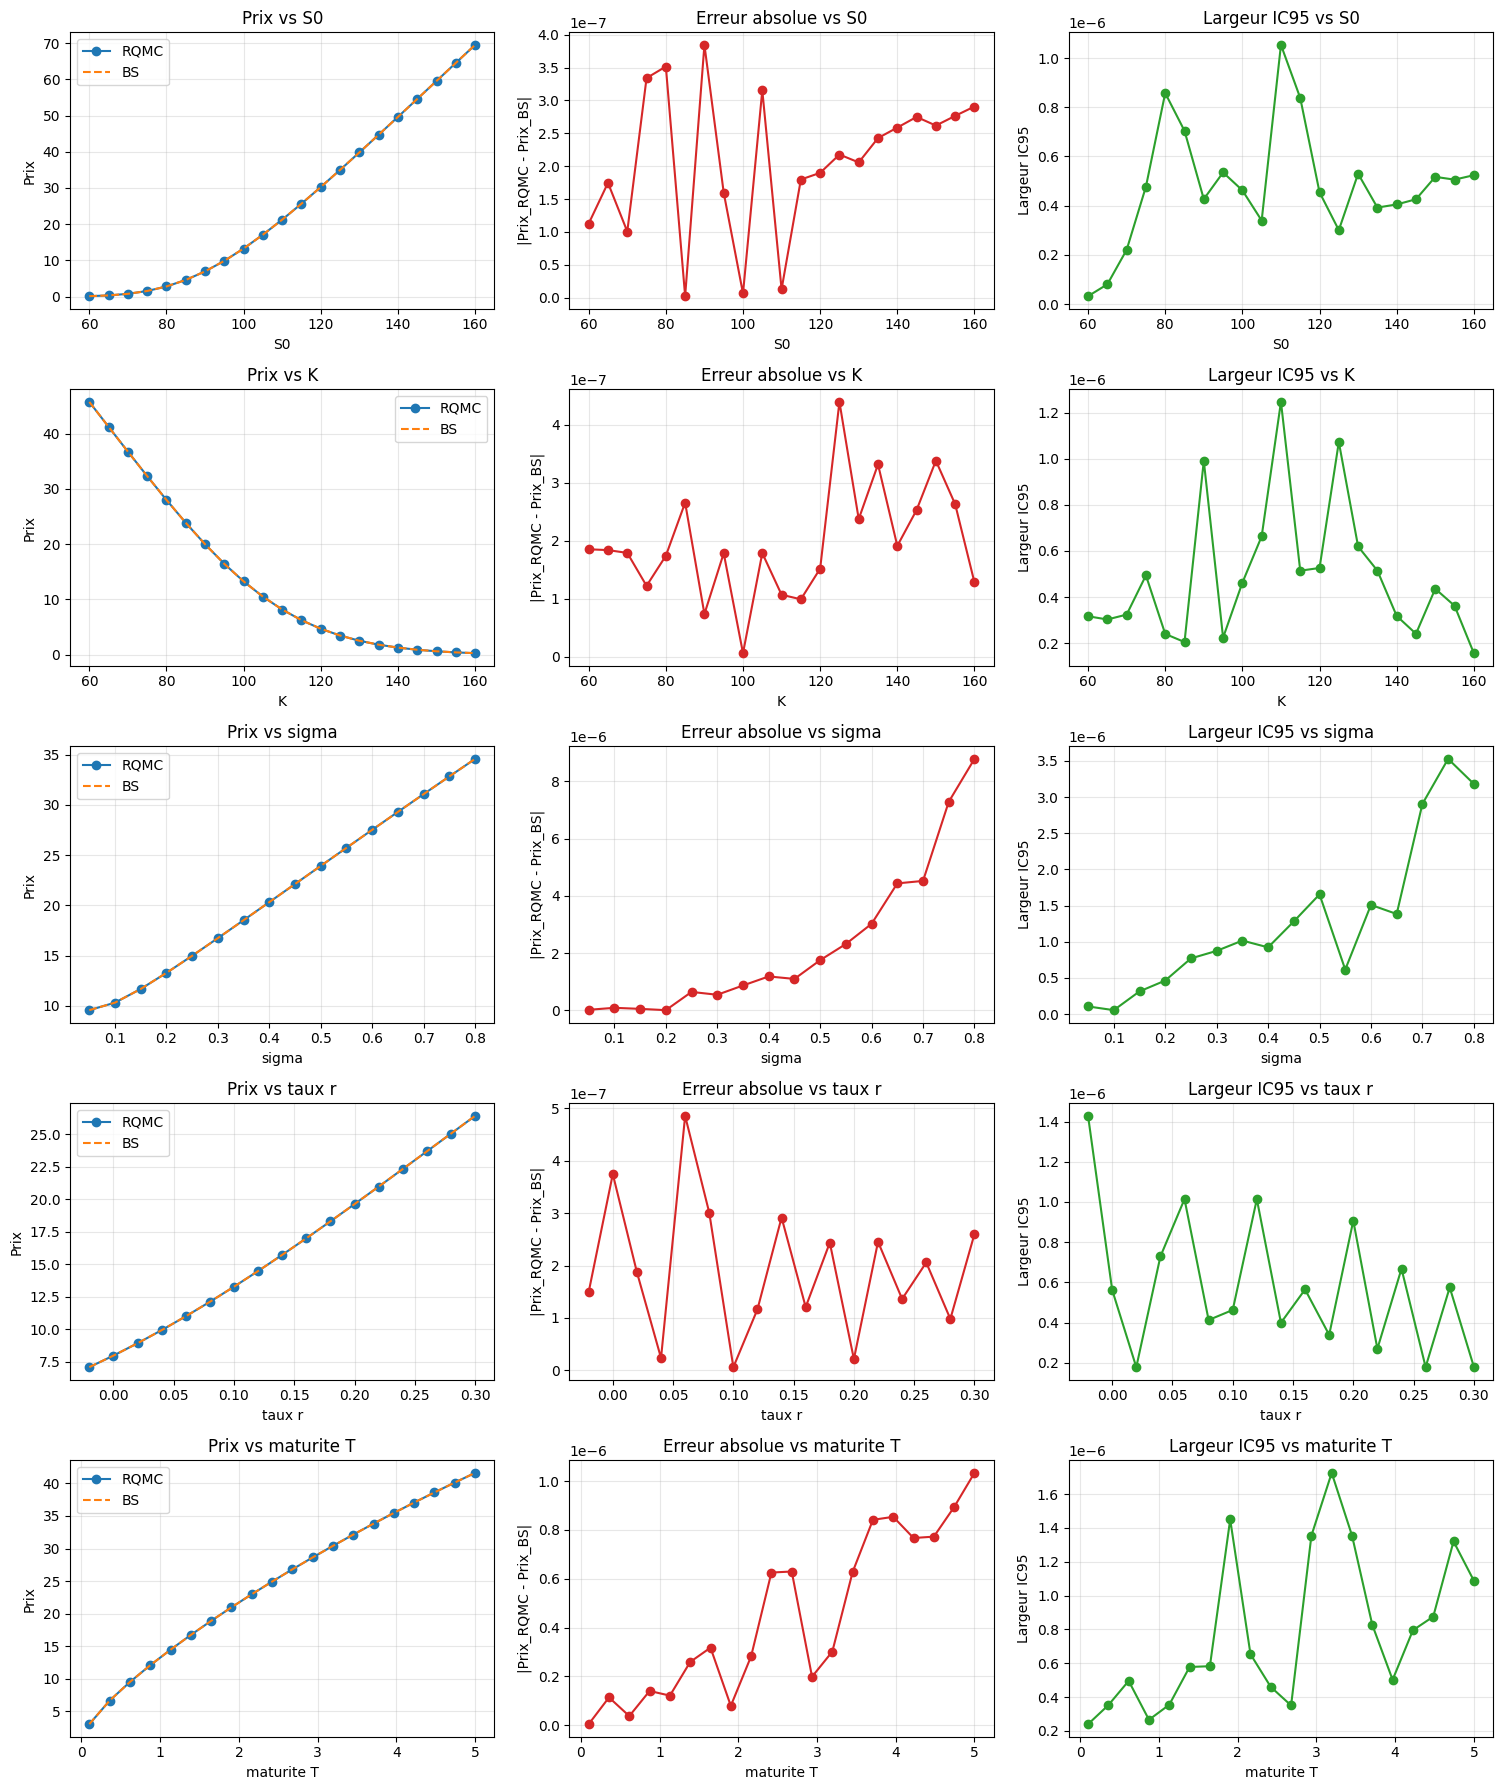


Synthèse (effet global par paramètre):
param  mean_abs_error  max_abs_error  mean_ci_width  max_ci_width
    K      0.00000019     0.00000044     0.00000049    0.00000125
   S0      0.00000021     0.00000038     0.00000048    0.00000105
    T      0.00000045     0.00000103     0.00000078    0.00000173
    r      0.00000019     0.00000049     0.00000058    0.00000143
sigma      0.00000229     0.00000878     0.00000129    0.00000353

Sensibilités locales normalisées (autour du cas de base):
param   base_value  dV_dparam_local  elasticity_local
   S0 100.00000000       0.72299206        5.44845279
    K 100.00000000      -0.59235595       -4.46398180
sigma   0.20000000      33.06661698        0.49837864
    r   0.10000000      59.26459248        0.44661671
    T   1.00000000       9.60923182        0.72414966


In [11]:
import matplotlib.pyplot as plt

params_order = ["S0", "K", "sigma", "r", "T"]
labels = {
    "S0": "S0",
    "K": "K",
    "sigma": "sigma",
    "r": "taux r",
    "T": "maturite T",
}

fig, axes = plt.subplots(len(params_order), 3, figsize=(15, 18))

for i, p in enumerate(params_order):
    d = df_sens[df_sens["param"] == p].sort_values("value")

    # (1) Prix RQMC vs valeur du paramètre
    axes[i, 0].plot(d["value"], d["price_rqmc"], marker="o", label="RQMC")
    axes[i, 0].plot(d["value"], d["price_bs"], linestyle="--", label="BS")
    axes[i, 0].set_title(f"Prix vs {labels[p]}")
    axes[i, 0].set_xlabel(labels[p])
    axes[i, 0].set_ylabel("Prix")
    axes[i, 0].grid(alpha=0.3)
    axes[i, 0].legend()

    # (2) Erreur absolue
    axes[i, 1].plot(d["value"], d["abs_error"], marker="o", color="tab:red")
    axes[i, 1].set_title(f"Erreur absolue vs {labels[p]}")
    axes[i, 1].set_xlabel(labels[p])
    axes[i, 1].set_ylabel("|Prix_RQMC - Prix_BS|")
    axes[i, 1].grid(alpha=0.3)

    # (3) Largeur IC95
    axes[i, 2].plot(d["value"], d["ci_width"], marker="o", color="tab:green")
    axes[i, 2].set_title(f"Largeur IC95 vs {labels[p]}")
    axes[i, 2].set_xlabel(labels[p])
    axes[i, 2].set_ylabel("Largeur IC95")
    axes[i, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tableau de synthèse par paramètre
summary = (
    df_sens.groupby("param", as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_ci_width=("ci_width", "mean"),
        max_ci_width=("ci_width", "max"),
    )
)

print("\nSynthèse (effet global par paramètre):")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\nSensibilités locales normalisées (autour du cas de base):")
print(df_local.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

### Lecture des résultats

Points à commenter dans le rapport:

1. **Sensibilité prix**: identifier les paramètres qui modifient le plus le prix (via `dV_dparam_local` et `elasticity_local`).
2. **Robustesse numérique**: vérifier que l'erreur absolue reste faible sur toute la grille.
3. **Stabilité statistique**: observer comment la largeur d'IC95 varie selon les paramètres.

En général, pour un call européen Black-Scholes:
- le prix est croissant en $S_0$, $\sigma$, $T$ et $r$,
- le prix est décroissant en $K$.

Ces courbes permettent de vérifier que la méthode RQMC conserve ces comportements attendus, tout en gardant une incertitude contrôlée.

## Chapitre 3 — Application aux options basket

On applique les deux variantes RQMC sur un call de panier arithmétique:

$$
\text{Payoff} = e^{-rT}\left(\sum_{i=1}^d w_i S_i(T) - K\right)^+.
$$

Objectif de cette section:

1. Construire une référence solide avec un **MC boosté** (grand N + antithétique + control variate).
2. Comparer **RQMC-Sobol + inverse CDF** et **RQMC-Sobol tronquée pondérée**.
3. Montrer que la variante ICDF reste stable quand la dimension augmente, contrairement à la variante tronquée pondérée.

In [21]:
import pandas as pd


def make_constant_corr_matrix(d, rho):
    corr = np.full((d, d), rho, dtype=float)
    np.fill_diagonal(corr, 1.0)
    return corr


def basket_terminal_values(z_corr, S0_vec, sigma_vec, r, T):
    drift = (r - 0.5 * sigma_vec**2) * T
    diffusion = sigma_vec * np.sqrt(T) * z_corr
    return S0_vec * np.exp(drift + diffusion)


def basket_discounted_payoff(z_corr, S0_vec, sigma_vec, w_vec, K, r, T):
    st = basket_terminal_values(z_corr, S0_vec, sigma_vec, r, T)
    basket = st @ w_vec
    return np.exp(-r * T) * np.maximum(basket - K, 0.0)


def mc_basket_price(S0_vec, sigma_vec, w_vec, K, r, T, corr, N=250_000, seed=123):
    d = len(S0_vec)
    rng = np.random.default_rng(seed)
    L = np.linalg.cholesky(corr)

    z = rng.standard_normal((N, d))
    z_corr = z @ L.T
    x = basket_discounted_payoff(z_corr, S0_vec, sigma_vec, w_vec, K, r, T)

    price = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(N)
    ci95 = (price - 1.96 * se, price + 1.96 * se)
    return {"price": price, "se": se, "ci95": ci95, "ci95_width": ci95[1] - ci95[0]}


def mc_basket_boosted_reference(S0_vec, sigma_vec, w_vec, K, r, T, corr, N=1_000_000, seed=777):
    # Reference MC: antithetic + control variate with known expectation
    d = len(S0_vec)
    n2 = N // 2
    rng = np.random.default_rng(seed)
    L = np.linalg.cholesky(corr)

    z = rng.standard_normal((n2, d))
    z_a = z @ L.T
    z_b = (-z) @ L.T

    st_a = basket_terminal_values(z_a, S0_vec, sigma_vec, r, T)
    st_b = basket_terminal_values(z_b, S0_vec, sigma_vec, r, T)

    payoff_a = np.exp(-r * T) * np.maximum(st_a @ w_vec - K, 0.0)
    payoff_b = np.exp(-r * T) * np.maximum(st_b @ w_vec - K, 0.0)
    y_pair = 0.5 * (payoff_a + payoff_b)

    # Control variate: discounted basket level, known mean = sum_i w_i S0_i
    ctrl_a = np.exp(-r * T) * (st_a @ w_vec)
    ctrl_b = np.exp(-r * T) * (st_b @ w_vec)
    c_pair = 0.5 * (ctrl_a + ctrl_b)
    c_mean = float(np.dot(w_vec, S0_vec))

    cov = np.cov(y_pair, c_pair, ddof=1)
    beta = cov[0, 1] / cov[1, 1]

    y_cv = y_pair - beta * (c_pair - c_mean)
    price = np.mean(y_cv)
    se = np.std(y_cv, ddof=1) / np.sqrt(n2)
    ci95 = (price - 1.96 * se, price + 1.96 * se)
    return {"price": price, "se": se, "ci95": ci95, "ci95_width": ci95[1] - ci95[0], "beta": beta}


def rqmc_basket_price_icdf(S0_vec, sigma_vec, w_vec, K, r, T, corr, N=16384, R=12, seed=2026):
    # Stable multi-dimensional variant
    d = len(S0_vec)
    L = np.linalg.cholesky(corr)
    m = int(np.ceil(np.log2(N)))

    estimates = np.empty(R, dtype=float)
    for rep in range(R):
        eng = qmc.Sobol(d=d, scramble=True, seed=seed + rep)
        u = eng.random_base2(m=m)[:N, :]
        u = np.clip(u, np.finfo(float).eps, 1.0 - np.finfo(float).eps)

        z = norm.ppf(u)
        z_corr = z @ L.T
        x = basket_discounted_payoff(z_corr, S0_vec, sigma_vec, w_vec, K, r, T)
        estimates[rep] = np.mean(x)

    price = np.mean(estimates)
    se = np.std(estimates, ddof=1) / np.sqrt(R)
    ci95 = (price - 1.96 * se, price + 1.96 * se)
    return {"price": price, "se": se, "ci95": ci95, "ci95_width": ci95[1] - ci95[0], "rep_estimates": estimates}


def rqmc_basket_price_truncated(S0_vec, sigma_vec, w_vec, K, r, T, corr, N=16384, R=12, a=6.0, seed=2026):
    # Direct extension of 1D truncated weighted approach
    d = len(S0_vec)
    L = np.linalg.cholesky(corr)
    m = int(np.ceil(np.log2(N)))

    estimates = np.empty(R, dtype=float)
    for rep in range(R):
        eng = qmc.Sobol(d=d, scramble=True, seed=seed + rep)
        u = eng.random_base2(m=m)[:N, :]
        u = np.clip(u, np.finfo(float).eps, 1.0 - np.finfo(float).eps)

        z = -a + 2.0 * a * u
        z_corr = z @ L.T
        x = basket_discounted_payoff(z_corr, S0_vec, sigma_vec, w_vec, K, r, T)

        # Product weights become unstable as d grows
        w = np.prod((2.0 * a) * norm.pdf(z), axis=1)
        y = x * w
        estimates[rep] = np.mean(y)

    price = np.mean(estimates)
    se = np.std(estimates, ddof=1) / np.sqrt(R)
    ci95 = (price - 1.96 * se, price + 1.96 * se)
    return {"price": price, "se": se, "ci95": ci95, "ci95_width": ci95[1] - ci95[0], "rep_estimates": estimates}


def basket_compute_budget(d):
    # Budget adaptatif pour monter jusqu'a plusieurs dizaines d'assets
    if d <= 10:
        return {"N_ref": 1_000_000, "N_mc": 250_000, "N_rqmc": 16_384, "R_rqmc": 12}
    if d <= 20:
        return {"N_ref": 700_000, "N_mc": 200_000, "N_rqmc": 8_192, "R_rqmc": 10}
    if d <= 30:
        return {"N_ref": 500_000, "N_mc": 150_000, "N_rqmc": 8_192, "R_rqmc": 10}
    if d <= 40:
        return {"N_ref": 350_000, "N_mc": 120_000, "N_rqmc": 4_096, "R_rqmc": 8}
    return {"N_ref": 300_000, "N_mc": 100_000, "N_rqmc": 4_096, "R_rqmc": 8}


def run_basket_experiments():
    rows = []
    r_loc = float(r)
    T_loc = float(T)

    # Plusieurs dizaines d'assets
    dims = [2, 5, 10, 20, 30, 40, 50]
    corrs = [0.0, 0.3, 0.6]

    for d in dims:
        budget = basket_compute_budget(d)
        for rho_basket in corrs:
            S0_vec = np.full(d, 100.0)
            sigma_vec = np.full(d, 0.2)
            w_vec = np.full(d, 1.0 / d)
            K_basket = 100.0
            corr = make_constant_corr_matrix(d, rho_basket)

            ref = mc_basket_boosted_reference(
                S0_vec, sigma_vec, w_vec, K_basket, r_loc, T_loc, corr,
                N=budget["N_ref"], seed=777,
            )
            mc = mc_basket_price(
                S0_vec, sigma_vec, w_vec, K_basket, r_loc, T_loc, corr,
                N=budget["N_mc"], seed=123,
            )
            rqmc_icdf = rqmc_basket_price_icdf(
                S0_vec, sigma_vec, w_vec, K_basket, r_loc, T_loc, corr,
                N=budget["N_rqmc"], R=budget["R_rqmc"], seed=2026,
            )
            rqmc_trunc = rqmc_basket_price_truncated(
                S0_vec, sigma_vec, w_vec, K_basket, r_loc, T_loc, corr,
                N=budget["N_rqmc"], R=budget["R_rqmc"], a=6.0, seed=2026,
            )

            rows.append({
                "d": d,
                "rho_corr": rho_basket,
                "N_ref": budget["N_ref"],
                "N_mc": budget["N_mc"],
                "N_rqmc": budget["N_rqmc"],
                "R_rqmc": budget["R_rqmc"],
                "REF_MCboost_price": ref["price"],
                "REF_MCboost_IC95_width": ref["ci95_width"],
                "MC_price": mc["price"],
                "MC_abs_diff_REF": abs(mc["price"] - ref["price"]),
                "MC_IC95_width": mc["ci95_width"],
                "RQMC_ICDF_price": rqmc_icdf["price"],
                "RQMC_ICDF_abs_diff_REF": abs(rqmc_icdf["price"] - ref["price"]),
                "RQMC_ICDF_IC95_width": rqmc_icdf["ci95_width"],
                "RQMC_ICDF_ratio_vs_MC": rqmc_icdf["ci95_width"] / mc["ci95_width"],
                "RQMC_TRUNC_price": rqmc_trunc["price"],
                "RQMC_TRUNC_abs_diff_REF": abs(rqmc_trunc["price"] - ref["price"]),
                "RQMC_TRUNC_IC95_width": rqmc_trunc["ci95_width"],
                "RQMC_TRUNC_ratio_vs_MC": rqmc_trunc["ci95_width"] / mc["ci95_width"],
            })

    return pd.DataFrame(rows)


df_basket = run_basket_experiments()
print("Comparaison Basket avec reference MC boostee (dimensions jusqu'a 50)")
print(df_basket.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

Comparaison Basket avec reference MC boostee (dimensions jusqu'a 50)
 d   rho_corr   N_ref   N_mc  N_rqmc  R_rqmc  REF_MCboost_price  REF_MCboost_IC95_width    MC_price  MC_abs_diff_REF  MC_IC95_width  RQMC_ICDF_price  RQMC_ICDF_abs_diff_REF  RQMC_ICDF_IC95_width  RQMC_ICDF_ratio_vs_MC  RQMC_TRUNC_price  RQMC_TRUNC_abs_diff_REF  RQMC_TRUNC_IC95_width  RQMC_TRUNC_ratio_vs_MC
 2 0.00000000 1000000 250000   16384      12        11.43592066              0.01202606 11.43700327       0.00108262     0.09336128      11.43143537              0.00448528            0.00052884             0.00566446       11.43128088               0.00463978             0.00109484              0.01172696
 2 0.30000000 1000000 250000   16384      12        12.02542928              0.01057560 12.03465400       0.00922472     0.10432640      12.02400251              0.00142677            0.00054126             0.00518815       12.02446825               0.00096102             0.00112837              0.01081575
 2 0.60

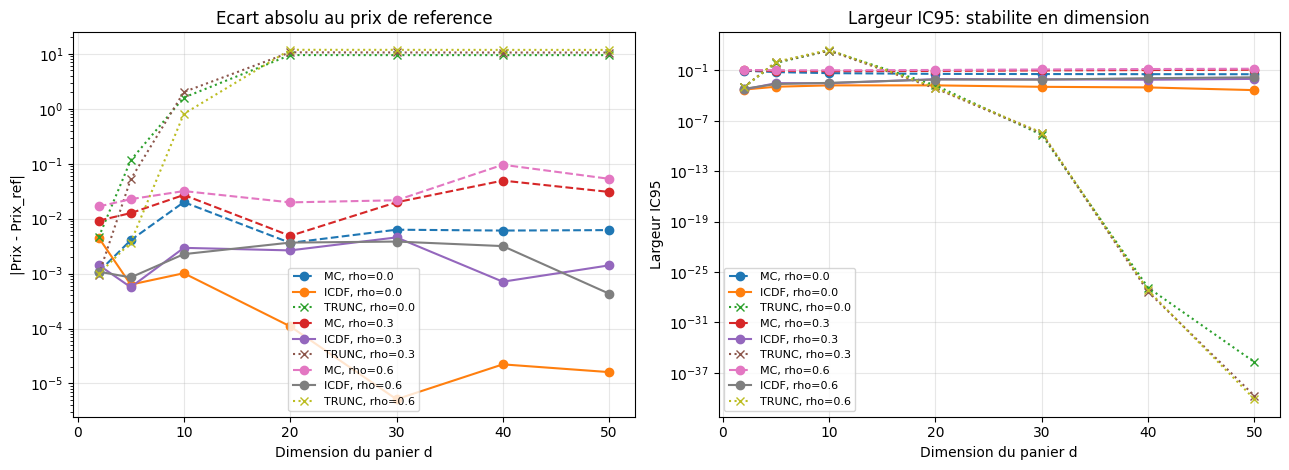


Tableau synthese (comparaison a la reference MC boostee):
 d   rho_corr  MC_abs_diff_REF  RQMC_ICDF_abs_diff_REF  RQMC_TRUNC_abs_diff_REF  MC_IC95_width  RQMC_ICDF_IC95_width  RQMC_TRUNC_IC95_width
 2 0.00000000       0.00108262              0.00448528               0.00463978     0.09336128            0.00052884             0.00109484
 2 0.30000000       0.00922472              0.00142677               0.00096102     0.10432640            0.00054126             0.00112837
 2 0.60000000       0.01667750              0.00108418               0.00099362     0.11429140            0.00064972             0.00098770
 5 0.00000000       0.00405519              0.00063027               0.11583162     0.06379833            0.00115223             0.78720590
 5 0.30000000       0.01264231              0.00056599               0.05200011     0.08801982            0.00304766             0.95484512
 5 0.60000000       0.02268014              0.00085232               0.00368331     0.10612096       

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for rho_basket in sorted(df_basket["rho_corr"].unique()):
    dsub = df_basket[df_basket["rho_corr"] == rho_basket].sort_values("d")

    # Stabilité en précision (écart à la référence MC boostée)
    axes[0].plot(dsub["d"], dsub["MC_abs_diff_REF"], marker="o", linestyle="--", label=f"MC, rho={rho_basket}")
    axes[0].plot(dsub["d"], dsub["RQMC_ICDF_abs_diff_REF"], marker="o", label=f"ICDF, rho={rho_basket}")
    axes[0].plot(dsub["d"], dsub["RQMC_TRUNC_abs_diff_REF"], marker="x", linestyle=":", label=f"TRUNC, rho={rho_basket}")

    # Stabilité statistique (largeur IC95)
    axes[1].plot(dsub["d"], dsub["MC_IC95_width"], marker="o", linestyle="--", label=f"MC, rho={rho_basket}")
    axes[1].plot(dsub["d"], dsub["RQMC_ICDF_IC95_width"], marker="o", label=f"ICDF, rho={rho_basket}")
    axes[1].plot(dsub["d"], dsub["RQMC_TRUNC_IC95_width"], marker="x", linestyle=":", label=f"TRUNC, rho={rho_basket}")

axes[0].set_title("Ecart absolu au prix de reference")
axes[0].set_xlabel("Dimension du panier d")
axes[0].set_ylabel("|Prix - Prix_ref|")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title("Largeur IC95: stabilite en dimension")
axes[1].set_xlabel("Dimension du panier d")
axes[1].set_ylabel("Largeur IC95")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nTableau synthese (comparaison a la reference MC boostee):")
print(df_basket[[
    "d", "rho_corr",
    "MC_abs_diff_REF", "RQMC_ICDF_abs_diff_REF", "RQMC_TRUNC_abs_diff_REF",
    "MC_IC95_width", "RQMC_ICDF_IC95_width", "RQMC_TRUNC_IC95_width"
]].to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\nLecture attendue:")
print("- ICDF: ecarts et IC95 restent contenus quand la dimension augmente.")
print("- TRUNC: ecarts et/ou IC95 se degradent fortement en grande dimension.")
print("- La reference MC boostee sert de benchmark commun pour juger la precision des deux variantes.")